# Lab 3 — Visualization notebook

**This notebook is a working tool, not a deliverable — you do NOT submit it.**

It contains no logic of its own: it imports your finished functions from `../src/lab03.py`
and plots their output. If a cell below fails, the bug is in your `.py`, not in the plot.

Your job: complete the three plot cells, then **export each figure and paste it into
`report.pdf`** (right-click → Save image as…, or `plt.savefig('fig1.png', dpi=150)`).
Figures 1–3 are required by the report template.

In [1]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
import lab03

data = lab03.load_data('../data/lab03_scene.npz')
X, labels_true = data['X'], data['labels']

rng = np.random.default_rng(lab03.SEED)
centers, km_labels, inertia = lab03.kmeans(X, lab03.K_OBJECTS, rng)      # Task 1
means, covs, weights, resp, lls = lab03.gmm_em(X, lab03.K_OBJECTS, rng)  # Task 2
gmm_labels = resp.argmax(axis=1)
print(f'{len(X)} pts, k-means inertia {inertia:.2f}, '
      f'ARI k-means {lab03.adjusted_rand_index(labels_true, km_labels):.4f}, '
      f'ARI GMM {lab03.adjusted_rand_index(labels_true, gmm_labels):.4f}')

1614 pts, k-means inertia 281.81, ARI k-means 0.6082, ARI GMM 0.9104


## Plot 1 — Report Figure 1: the scene, K-means vs GMM labels

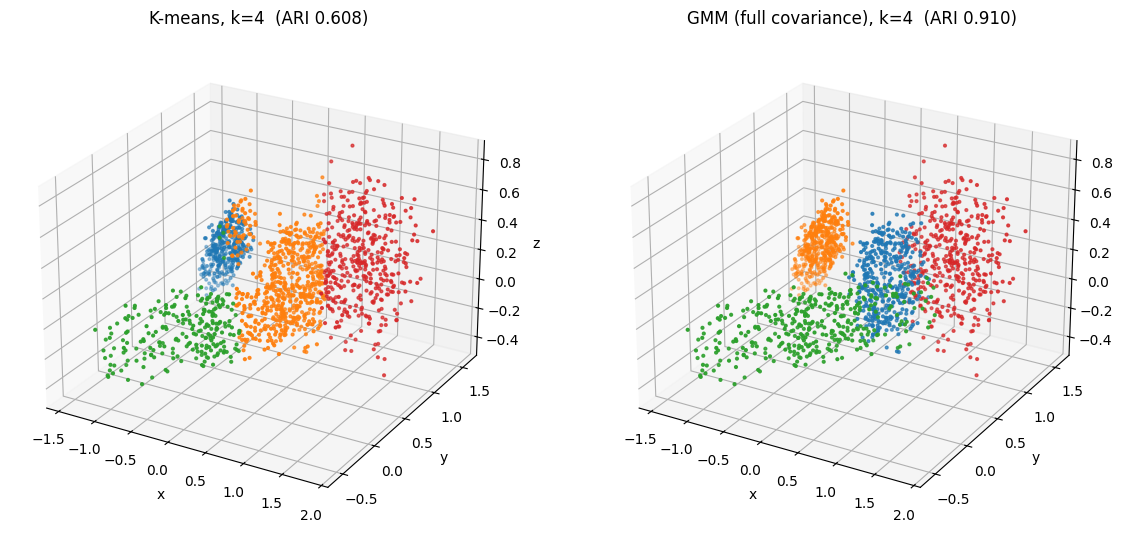

In [2]:
# Plot 1 — K-means vs GMM labels, same view
ari_km = lab03.adjusted_rand_index(labels_true, km_labels)
ari_gmm = lab03.adjusted_rand_index(labels_true, gmm_labels)
fig = plt.figure(figsize=(12, 5.5))
for i, (lab, name, ari) in enumerate([(km_labels, 'K-means', ari_km),
                                      (gmm_labels, 'GMM (full covariance)', ari_gmm)]):
    ax = fig.add_subplot(1, 2, i + 1, projection='3d')
    ax.scatter(*X.T, c=lab, cmap='tab10', vmin=0, vmax=9, s=4)
    ax.view_init(elev=25, azim=-60)
    ax.set(title=f'{name}, k={lab03.K_OBJECTS}  (ARI {ari:.3f})',
           xlabel='x', ylabel='y', zlabel='z')
plt.tight_layout()
plt.savefig('../fig1.png', dpi=150)
plt.show()


## Plot 2 — Report Figure 2: the EM log-likelihood trace

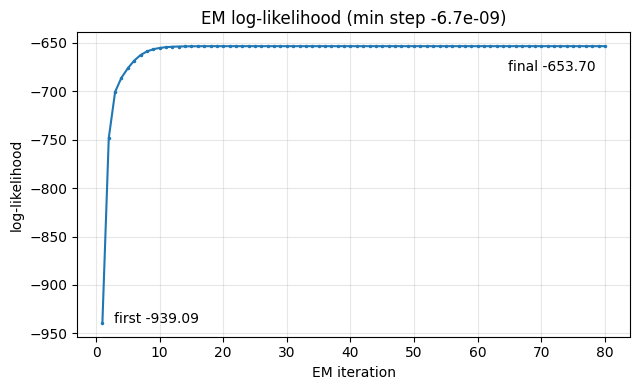

In [3]:
# Plot 2 — EM log-likelihood trace
it = np.arange(1, len(lls) + 1)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(it, lls, marker='.', ms=3)
ax.annotate(f'first {lls[0]:.2f}', (1, lls[0]), xytext=(8, 0), textcoords='offset points')
ax.annotate(f'final {lls[-1]:.2f}', (it[-1], lls[-1]), xytext=(-70, -18), textcoords='offset points')
ax.set(xlabel='EM iteration', ylabel='log-likelihood',
       title=f'EM log-likelihood (min step {np.diff(lls).min():.1e})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../fig2.png', dpi=150)
plt.show()


## Plot 3 — Report Figure 3: the BIC curve

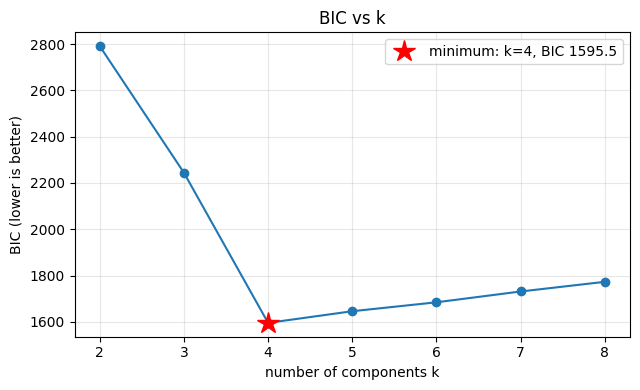

{2: np.float64(2791.0291), 3: np.float64(2244.1721), 4: np.float64(1595.4747), 5: np.float64(1645.8338), 6: np.float64(1684.4573), 7: np.float64(1731.1309), 8: np.float64(1772.8624)}


In [4]:
# Plot 3 — BIC curve (same rng as the setup cell -> matches results.json)
bics, best_k = lab03.select_k(X, lab03.K_RANGE, rng)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(lab03.K_RANGE, bics, marker='o')
ax.plot(best_k, min(bics), 'r*', ms=16, label=f'minimum: k={best_k}, BIC {min(bics):.1f}')
ax.set(xlabel='number of components k', ylabel='BIC (lower is better)', title='BIC vs k')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../fig3.png', dpi=150)
plt.show()
print(dict(zip(lab03.K_RANGE, np.round(bics, 4))))
